# Clinical Risk Analysis using Diabetes Dataset

## 1. Introduction

This project performs an end-to-end clinical data analysis pipeline using the PIMA Indians Diabetes Dataset. The study includes data preprocessing, exploratory data analysis, statistical evaluation, SQL-based querying, machine learning model development, and interpretation of clinical risk factors associated with diabetes. The objective is not only to develop predictive models but also to understand how healthcare data can support evidence-based clinical decision-making.

## 2. Import Libraries

In [15]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_curve, roc_auc_score, confusion_matrix
import joblib # For saving models

# Set plotting style
sns.set_style("whitegrid")

## 3. Setup Directories

In [16]:
# Ensure necessary directories exist
MODELS_DIR = 'models'
VISUALIZATIONS_DIR = 'visualizations'
SQL_DIR = 'sql'

os.makedirs(MODELS_DIR, exist_ok=True)
os.makedirs(VISUALIZATIONS_DIR, exist_ok=True)
os.makedirs(SQL_DIR, exist_ok=True)

print(f"Created directories: {MODELS_DIR}/, {VISUALIZATIONS_DIR}/, {SQL_DIR}/")

Created directories: models/, visualizations/, sql/


In [31]:
# Ensure results directory exists
RESULTS_DIR = 'results'
os.makedirs(RESULTS_DIR, exist_ok=True)
print(f"Created directory: {RESULTS_DIR}/")

Created directory: results/


## 4. Load Dataset

### Data Loading and Initial Inspection

In [17]:
# Assuming the 'diabetes.csv' dataset is present in the 'data/' directory
# If not, please ensure it is placed there or download it from Kaggle:
# https://www.kaggle.com/datasets/uciml/pima-indians-diabetes-database

DATA_DIR = 'data'
DATA_FILE = os.path.join(DATA_DIR, 'diabetes.csv')

# Ensure the data directory exists
os.makedirs(DATA_DIR, exist_ok=True)

if not os.path.exists(DATA_FILE):
    print(f"Error: '{DATA_FILE}' not found. Please ensure the 'diabetes.csv' file is placed in the '{DATA_DIR}/' folder.")
    print("You can download it from: https://www.kaggle.com/datasets/uciml/pima-indians-diabetes-database")
else:
    # Load the dataset
    df = pd.read_csv(DATA_FILE)
    print(f"'{DATA_FILE}' loaded successfully. Initial shape: {df.shape}")

'data/diabetes.csv' loaded successfully. Initial shape: (768, 9)


## 5. Dataset Overview

In [18]:
if 'df' in locals(): # Check if df was loaded successfully
    print("First 5 rows of the dataset:")
    display(df.head())

    print("\nDataset Information:")
    display(df.info())
else:
    print("DataFrame 'df' not found. Please ensure 'diabetes.csv' was loaded successfully in the previous step.")

First 5 rows of the dataset:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1



Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


None

### Dataset Feature Descriptions

| Feature | Description |
| :----------------------- | :------------------------------------------------------------------------ |
| **Pregnancies** | Number of times pregnant |
| **Glucose** | Plasma glucose concentration a 2 hours in an oral glucose tolerance test |
| **BloodPressure** | Diastolic blood pressure (mm Hg) |
| **SkinThickness** | Triceps skin fold thickness (mm) |
| **Insulin** | 2-Hour serum insulin (mu U/ml) |
| **BMI** | Body mass index (weight in kg/(height in m)^2) |
| **DiabetesPedigreeFunction** | A function that scores likelihood of diabetes based on family history |
| **Age** | Age in years |
| **Outcome** | Class variable (0: non-diabetic, 1: diabetic) |


## 6. Data Cleaning

In [19]:
print("--- Data Cleaning ---")

# 1. Handling Missing Values (replacing 0s with NaN in specific columns)
# Columns where 0 is not a valid value and likely represents a missing entry
columns_with_zeros_as_missing = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

print(f"Number of 0s before replacement in key columns:\n{df[columns_with_zeros_as_missing].eq(0).sum()}")

df[columns_with_zeros_as_missing] = df[columns_with_zeros_as_missing].replace(0, np.nan)

print(f"Number of NaNs after replacement:\n{df[columns_with_zeros_as_missing].isnull().sum()}")

# 2. Removing duplicate rows
initial_rows = df.shape[0]
df.drop_duplicates(inplace=True)
duplicate_rows_removed = initial_rows - df.shape[0]
print(f"\nRemoved {duplicate_rows_removed} duplicate rows.")

# 3. Checking for any remaining missing values after 0-replacement
print("\nTotal missing values per column after 0-replacement:")
display(df.isnull().sum())

# Impute NaNs with the median of their respective columns.
for column in columns_with_zeros_as_missing:
    if df[column].isnull().any():
        median_val = df[column].median()
        df[column] = df[column].fillna(median_val)
        print(f"Filled NaN values in '{column}' with median: {median_val}")

print("\nMissing values after median imputation:")
display(df.isnull().sum())

# 4. Outlier detection (placeholder - will be addressed later if needed)
print("\nOutlier detection will be addressed later as part of EDA or advanced preprocessing.")

# 5. Convert data types (check if all types are appropriate, if not, convert)
# For this dataset, the types seem generally appropriate. Converting int64 columns that may now have float values to float if they were part of the imputation.
for col in ['Pregnancies', 'Age', 'Outcome']:
    if df[col].dtype == 'float64' and (df[col] % 1 == 0).all():
        df[col] = df[col].astype('int64')

print("\nData types after cleaning:")
display(df.info())

# Display the first few rows after cleaning
print("\nFirst 5 rows of the dataset after cleaning:")
display(df.head())

# Save the cleaned data to a new CSV file
CLEANED_DATA_FILE = os.path.join(DATA_DIR, 'cleaned_diabetes.csv')
df.to_csv(CLEANED_DATA_FILE, index=False)
print(f"\nCleaned data saved to '{CLEANED_DATA_FILE}'")

--- Data Cleaning ---
Number of 0s before replacement in key columns:
Glucose            5
BloodPressure     35
SkinThickness    227
Insulin          374
BMI               11
dtype: int64
Number of NaNs after replacement:
Glucose            5
BloodPressure     35
SkinThickness    227
Insulin          374
BMI               11
dtype: int64

Removed 0 duplicate rows.

Total missing values per column after 0-replacement:


,0
Pregnancies,0
Glucose,5
BloodPressure,35
SkinThickness,227
Insulin,374
BMI,11
DiabetesPedigreeFunction,0
Age,0
Outcome,0


Filled NaN values in 'Glucose' with median: 117.0
Filled NaN values in 'BloodPressure' with median: 72.0
Filled NaN values in 'SkinThickness' with median: 29.0
Filled NaN values in 'Insulin' with median: 125.0
Filled NaN values in 'BMI' with median: 32.3

Missing values after median imputation:


,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0



Outlier detection will be addressed later as part of EDA or advanced preprocessing.

Data types after cleaning:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    float64
 2   BloodPressure             768 non-null    float64
 3   SkinThickness             768 non-null    float64
 4   Insulin                   768 non-null    float64
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(6), int64(3)
memory usage: 54.1 KB


None


First 5 rows of the dataset after cleaning:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148.0,72.0,35.0,125.0,33.6,0.627,50,1
1,1,85.0,66.0,29.0,125.0,26.6,0.351,31,0
2,8,183.0,64.0,29.0,125.0,23.3,0.672,32,1
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21,0
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33,1



Cleaned data saved to 'data/cleaned_diabetes.csv'


## 7. Exploratory Data Analysis


--- Exploratory Data Analysis ---

Descriptive Statistics:


,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,3.845052,3.369578,0.000,1.00000,3.0000,6.00000,17.00
Glucose,768.0,121.656250,30.438286,44.000,99.75000,117.0000,140.25000,199.00
BloodPressure,768.0,72.386719,12.096642,24.000,64.00000,72.0000,80.00000,122.00
SkinThickness,768.0,29.108073,8.791221,7.000,25.00000,29.0000,32.00000,99.00
Insulin,768.0,140.671875,86.383060,14.000,121.50000,125.0000,127.25000,846.00
BMI,768.0,32.455208,6.875177,18.200,27.50000,32.3000,36.60000,67.10
DiabetesPedigreeFunction,768.0,0.471876,0.331329,0.078,0.24375,0.3725,0.62625,2.42
Age,768.0,33.240885,11.760232,21.000,24.00000,29.0000,41.00000,81.00
Outcome,768.0,0.348958,0.476951,0.000,0.00000,0.0000,1.00000,1.00



Number of non-diabetic (0) and diabetic (1) patients:
Outcome
0    500
1    268
Name: count, dtype: int64


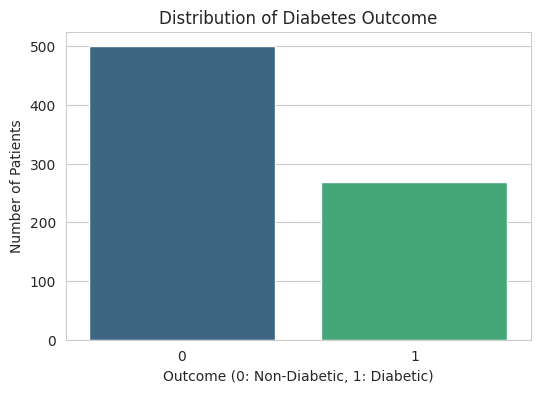

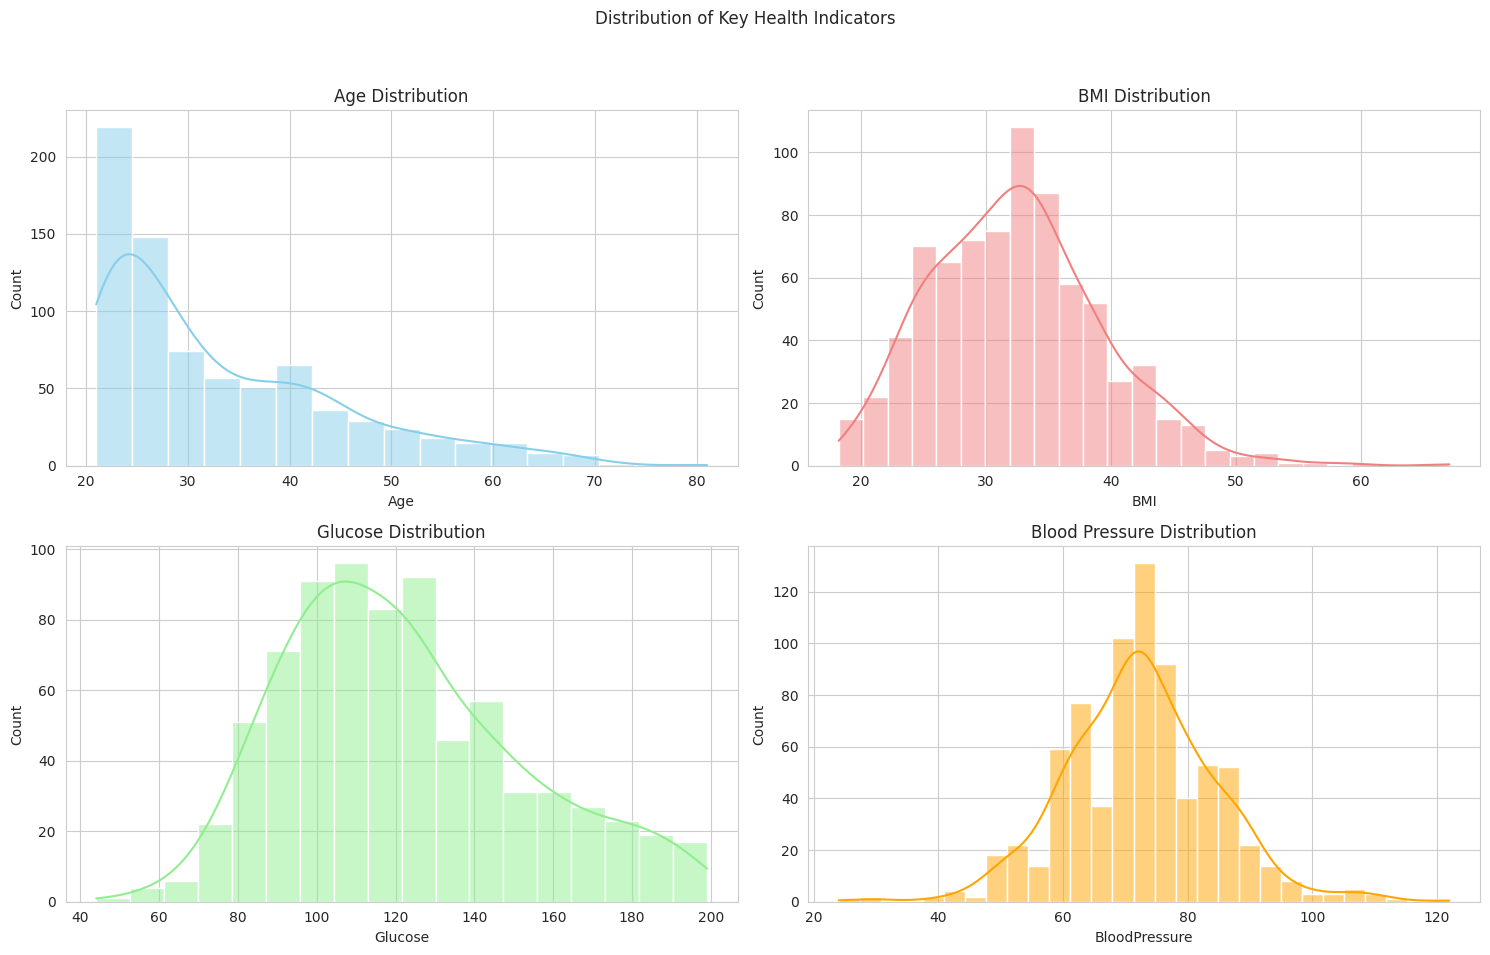

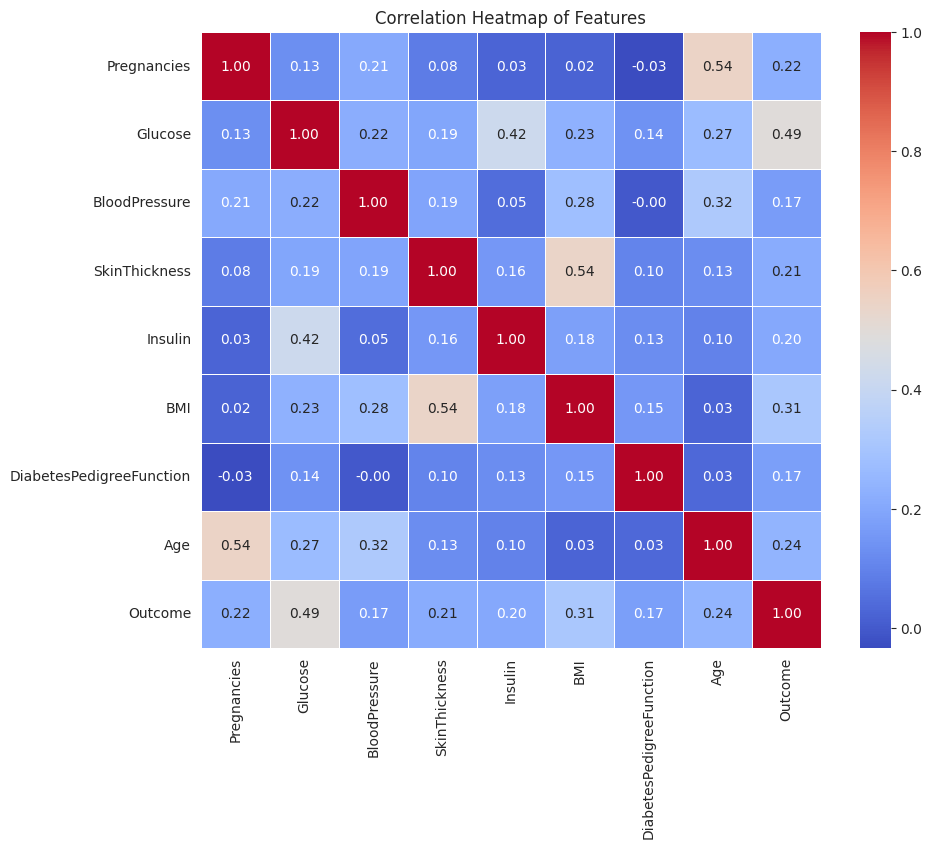

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set plotting style
sns.set_style("whitegrid")

print("\n--- Exploratory Data Analysis ---")

# 1. Descriptive Statistics
print("\nDescriptive Statistics:")
display(df.describe().T)

# 2. How many diabetic patients?
outcome_counts = df['Outcome'].value_counts()
print(f"\nNumber of non-diabetic (0) and diabetic (1) patients:\n{outcome_counts}")

plt.figure(figsize=(6, 4))
# Fix FutureWarning by explicitly setting hue or removing palette if not needed for hue
sns.countplot(x='Outcome', data=df, palette='viridis', hue='Outcome', legend=False)
plt.title('Distribution of Diabetes Outcome')
plt.xlabel('Outcome (0: Non-Diabetic, 1: Diabetic)')
plt.ylabel('Number of Patients')
plt.savefig(os.path.join(VISUALIZATIONS_DIR, 'outcome_distribution.png'), dpi=300, bbox_inches='tight')
plt.show()

# 3. Distribution of key features (Age, BMI, Glucose, BloodPressure)
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Distribution of Key Health Indicators')

sns.histplot(df['Age'], kde=True, ax=axes[0, 0], color='skyblue')
axes[0, 0].set_title('Age Distribution')
plt.savefig(os.path.join(VISUALIZATIONS_DIR, 'age_distribution.png'), dpi=300, bbox_inches='tight')

sns.histplot(df['BMI'], kde=True, ax=axes[0, 1], color='lightcoral')
axes[0, 1].set_title('BMI Distribution')
plt.savefig(os.path.join(VISUALIZATIONS_DIR, 'bmi_distribution.png'), dpi=300, bbox_inches='tight')

sns.histplot(df['Glucose'], kde=True, ax=axes[1, 0], color='lightgreen')
axes[1, 0].set_title('Glucose Distribution')
plt.savefig(os.path.join(VISUALIZATIONS_DIR, 'glucose_distribution.png'), dpi=300, bbox_inches='tight')

sns.histplot(df['BloodPressure'], kde=True, ax=axes[1, 1], color='orange')
axes[1, 1].set_title('Blood Pressure Distribution')
plt.savefig(os.path.join(VISUALIZATIONS_DIR, 'bloodpressure_distribution.png'), dpi=300, bbox_inches='tight')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# 4. Correlation Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Heatmap of Features')
plt.savefig(os.path.join(VISUALIZATIONS_DIR, 'correlation_heatmap.png'), dpi=300, bbox_inches='tight')
plt.show()

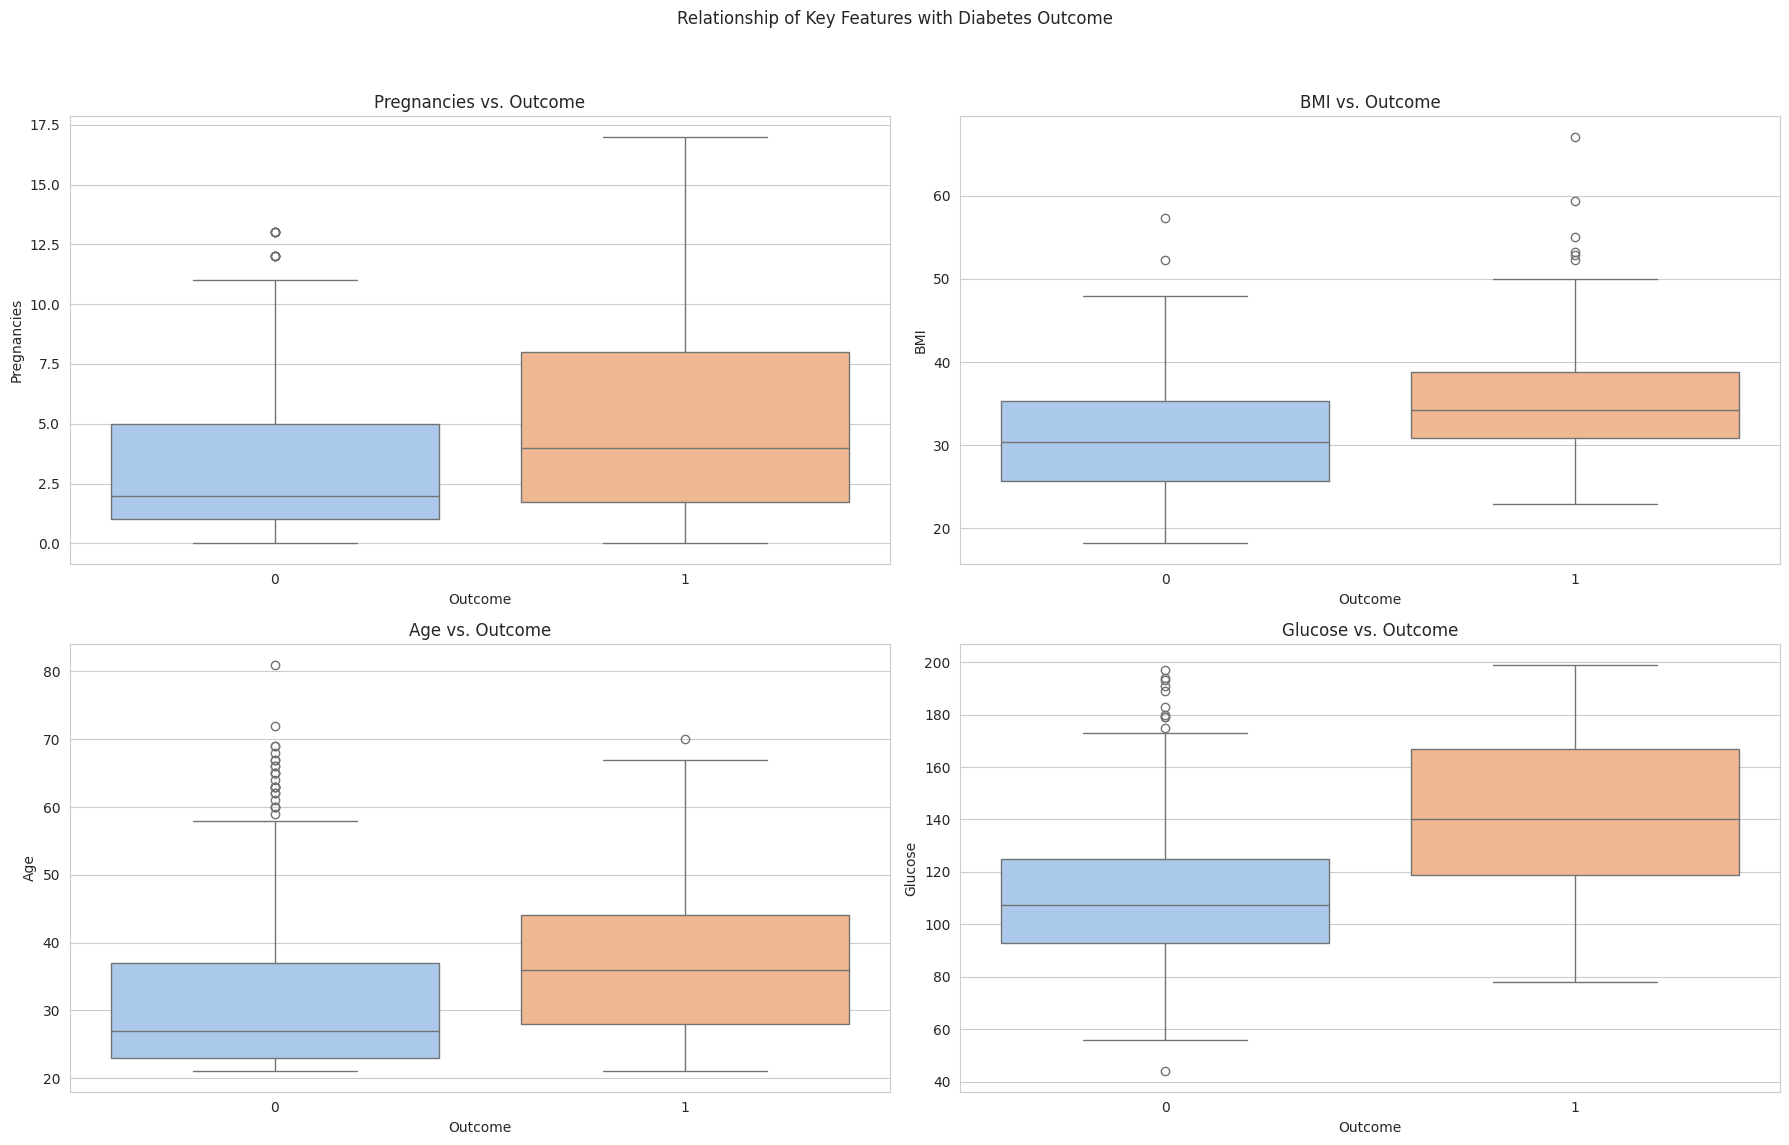

In [21]:
# 5. Relationships with Outcome (Pregnancy, BMI, Age, Glucose)
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle('Relationship of Key Features with Diabetes Outcome')

# Fix FutureWarning by explicitly setting hue or removing palette if not needed for hue
sns.boxplot(x='Outcome', y='Pregnancies', data=df, ax=axes[0, 0], palette='pastel', hue='Outcome', legend=False)
axes[0, 0].set_title('Pregnancies vs. Outcome')

sns.boxplot(x='Outcome', y='BMI', data=df, ax=axes[0, 1], palette='pastel', hue='Outcome', legend=False)
axes[0, 1].set_title('BMI vs. Outcome')

sns.boxplot(x='Outcome', y='Age', data=df, ax=axes[1, 0], palette='pastel', hue='Outcome', legend=False)
axes[1, 0].set_title('Age vs. Outcome')

sns.boxplot(x='Outcome', y='Glucose', data=df, ax=axes[1, 1], palette='pastel', hue='Outcome', legend=False)
axes[1, 1].set_title('Glucose vs. Outcome')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig(os.path.join(VISUALIZATIONS_DIR, 'feature_outcome_relationships.png'), dpi=300, bbox_inches='tight')
plt.show()

## 8. Statistical Analysis

In [6]:
print("\n--- Statistical Analysis ---")

# Mean
print("\nMean of each feature:")
display(df.mean())

# Median
print("\nMedian of each feature:")
display(df.median())

# Variance
print("\nVariance of each feature:")
display(df.var())

# Standard Deviation
print("\nStandard Deviation of each feature:")
display(df.std())

# Covariance Matrix
print("\nCovariance Matrix:")
display(df.cov())

# Correlation Matrix (already visualized in EDA, but can be displayed numerically)
print("\nCorrelation Matrix (numeric):")
display(df.corr())


--- Statistical Analysis ---

Mean of each feature:


,0
Pregnancies,3.845052
Glucose,120.894531
BloodPressure,69.105469
SkinThickness,20.536458
Insulin,79.799479
BMI,31.992578
DiabetesPedigreeFunction,0.471876
Age,33.240885
Outcome,0.348958



Median of each feature:


,0
Pregnancies,3.0000
Glucose,117.0000
BloodPressure,72.0000
SkinThickness,23.0000
Insulin,30.5000
BMI,32.0000
DiabetesPedigreeFunction,0.3725
Age,29.0000
Outcome,0.0000



Variance of each feature:


...

,0
Pregnancies,3.369578
Glucose,31.972618
BloodPressure,19.355807
SkinThickness,15.952218
Insulin,115.244002
BMI,7.884160
DiabetesPedigreeFunction,0.331329
Age,11.760232
Outcome,0.476951



Covariance Matrix:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
Pregnancies,11.354056,13.947131,9.214538,-4.390041,-28.555231,0.469774,-0.037426,21.570620,0.356618
Glucose,13.947131,1022.248314,94.430956,29.239183,1220.935799,55.726987,1.454875,99.082805,7.115079
BloodPressure,9.214538,94.430956,374.647271,64.029396,198.378412,43.004695,0.264638,54.523453,0.600697
SkinThickness,-4.390041,29.239183,64.029396,254.473245,802.979941,49.373869,0.972136,-21.381023,0.568747
Insulin,-28.555231,1220.935799,198.378412,802.979941,13281.180078,179.775172,7.066681,-57.143290,7.175671
BMI,0.469774,55.726987,43.004695,49.373869,179.775172,62.159984,0.367405,3.360330,1.100638
DiabetesPedigreeFunction,-0.037426,1.454875,0.264638,0.972136,7.066681,0.367405,0.109779,0.130772,0.027472
Age,21.570620,99.082805,54.523453,-21.381023,-57.143290,3.360330,0.130772,138.303046,1.336953
Outcome,0.356618,7.115079,0.600697,0.568747,7.175671,1.100638,0.027472,1.336953,0.227483



Correlation Matrix (numeric):


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
Pregnancies,1.000000,0.129459,0.141282,-0.081672,-0.073535,0.017683,-0.033523,0.544341,0.221898
Glucose,0.129459,1.000000,0.152590,0.057328,0.331357,0.221071,0.137337,0.263514,0.466581
BloodPressure,0.141282,0.152590,1.000000,0.207371,0.088933,0.281805,0.041265,0.239528,0.065068
SkinThickness,-0.081672,0.057328,0.207371,1.000000,0.436783,0.392573,0.183928,-0.113970,0.074752
Insulin,-0.073535,0.331357,0.088933,0.436783,1.000000,0.197859,0.185071,-0.042163,0.130548
BMI,0.017683,0.221071,0.281805,0.392573,0.197859,1.000000,0.140647,0.036242,0.292695
DiabetesPedigreeFunction,-0.033523,0.137337,0.041265,0.183928,0.185071,0.140647,1.000000,0.033561,0.173844
Age,0.544341,0.263514,0.239528,-0.113970,-0.042163,0.036242,0.033561,1.000000,0.238356
Outcome,0.221898,0.466581,0.065068,0.074752,0.130548,0.292695,0.173844,0.238356,1.000000


## 9. SQL Analysis

In [22]:
print("\n--- SQL Analysis ---")

# Create an in-memory SQLite database
conn = sqlite3.connect(':memory:')

# Load the pandas DataFrame into the SQLite database
df.to_sql('diabetes_data', conn, if_exists='replace', index=False)

print("Dataset loaded into SQLite database as 'diabetes_data' table.")

# Define SQL queries as a dictionary for easy management
sql_queries = {
    "average_bmi": "SELECT AVG(BMI) AS Average_BMI FROM diabetes_data;",
    "max_glucose": "SELECT MAX(Glucose) AS Highest_Glucose FROM diabetes_data;",
    "avg_age": "SELECT AVG(Age) AS Average_Age FROM diabetes_data;",
    "diabetic_count": "SELECT COUNT(*) AS Diabetic_Patients_Count FROM diabetes_data WHERE Outcome = 1;",
    "patients_over_50": "SELECT * FROM diabetes_data WHERE Age > 50;",
    "patients_bmi_gt_30": "SELECT COUNT(*) AS Patients_BMI_GT_30 FROM diabetes_data WHERE BMI > 30;",
    "avg_glucose_by_outcome": "SELECT Outcome, AVG(Glucose) AS Average_Glucose FROM diabetes_data GROUP BY Outcome;"
}

# Save SQL queries to a file
SQL_FILE_PATH = os.path.join(SQL_DIR, 'diabetes_queries.sql')
with open(SQL_FILE_PATH, 'w') as f:
    for name, query in sql_queries.items():
        f.write(f"-- {name.replace('_', ' ').title()}\n{query}\n\n")
print(f"All SQL queries saved to '{SQL_FILE_PATH}'")

def run_sql_query(query, query_name=""): # Added query_name for better output
    """Helper function to run SQL queries and display results."""
    try:
        result_df = pd.read_sql_query(query, conn)
        print(f"\nQuery Result for '{query_name or 'Unnamed Query'}':\n{query}")
        display(result_df)
    except Exception as e:
        print(f"Error executing query '{query_name}': {e}")

# Execute example SQL Queries from the notebook
for name, query in sql_queries.items():
    run_sql_query(query, name)

# Close the connection (important for file-based databases, less critical for in-memory)
# For the purpose of demonstration, we'll keep it open for subsequent queries if any, then close.
conn.close()
print("\nSQLite database connection closed.")


--- SQL Analysis ---
Dataset loaded into SQLite database as 'diabetes_data' table.
All SQL queries saved to 'sql/diabetes_queries.sql'

Query Result for 'average_bmi':
SELECT AVG(BMI) AS Average_BMI FROM diabetes_data;


,Average_BMI
0,32.455208



Query Result for 'max_glucose':
SELECT MAX(Glucose) AS Highest_Glucose FROM diabetes_data;


,Highest_Glucose
0,199.0



Query Result for 'avg_age':
SELECT AVG(Age) AS Average_Age FROM diabetes_data;


...


Query Result for 'patients_bmi_gt_30':
SELECT COUNT(*) AS Patients_BMI_GT_30 FROM diabetes_data WHERE BMI > 30;


,Patients_BMI_GT_30
0,476



Query Result for 'avg_glucose_by_outcome':
SELECT Outcome, AVG(Glucose) AS Average_Glucose FROM diabetes_data GROUP BY Outcome;


,Outcome,Average_Glucose
0,0,110.682000
1,1,142.130597



SQLite database connection closed.


## 10. Machine Learning

In [23]:
print("\n--- Machine Learning ---")

# Define features (X) and target (y)
X = df.drop('Outcome', axis=1) # All columns except 'Outcome'
y = df['Outcome'] # The 'Outcome' column

# Split the dataset into training and testing sets
# Using a 70/30 split, and stratify by 'y' to maintain the proportion of outcomes in both sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

print(f"Training set size: {len(X_train)} samples")
print(f"Testing set size: {len(X_test)} samples")
print(f"Outcome distribution in training set:\n{y_train.value_counts(normalize=True)}")
print(f"Outcome distribution in testing set:\n{y_test.value_counts(normalize=True)}")


--- Machine Learning ---
Training set size: 537 samples
Testing set size: 231 samples
Outcome distribution in training set:
Outcome
0    0.651769
1    0.348231
Name: proportion, dtype: float64
Outcome distribution in testing set:
Outcome
0    0.649351
1    0.350649
Name: proportion, dtype: float64


### Logistic Regression


Training Logistic Regression Model...

--- Logistic Regression Model Evaluation ---
Accuracy: 0.7489
Precision: 0.6949
Recall: 0.5062
F1-Score: 0.5857


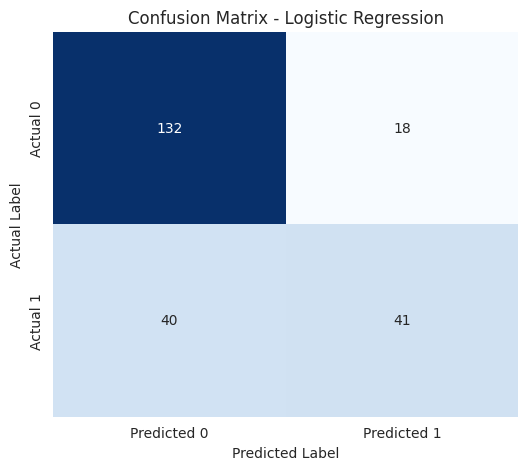

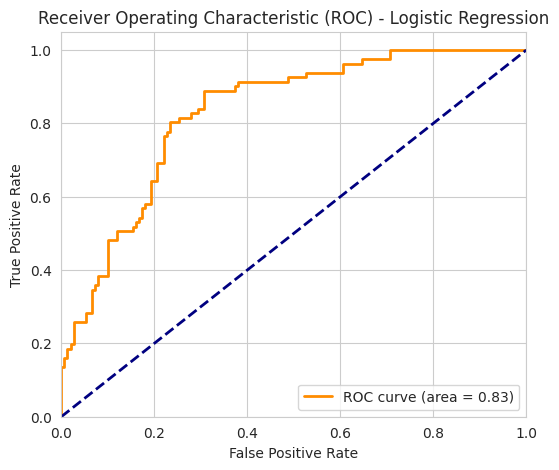

Logistic Regression model saved to 'models/logistic_regression.pkl'


In [24]:
# Initialize and train Logistic Regression model
print("\nTraining Logistic Regression Model...")
log_reg_model = LogisticRegression(random_state=42, solver='liblinear', max_iter=200)
log_reg_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_lr = log_reg_model.predict(X_test)
y_prob_lr = log_reg_model.predict_proba(X_test)[:, 1]

# Evaluate Logistic Regression model
print("\n--- Logistic Regression Model Evaluation ---")
accuracy_lr = accuracy_score(y_test, y_pred_lr)
precision_lr = precision_score(y_test, y_pred_lr)
recall_lr = recall_score(y_test, y_pred_lr)
f1_lr = f1_score(y_test, y_pred_lr)

print(f"Accuracy: {accuracy_lr:.4f}")
print(f"Precision: {precision_lr:.4f}")
print(f"Recall: {recall_lr:.4f}")
print(f"F1-Score: {f1_lr:.4f}")

# Confusion Matrix
cm_lr = confusion_matrix(y_test, y_pred_lr)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted 0', 'Predicted 1'], yticklabels=['Actual 0', 'Actual 1'])
plt.title('Confusion Matrix - Logistic Regression')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.savefig(os.path.join(VISUALIZATIONS_DIR, 'confusion_matrix_lr.png'), dpi=300, bbox_inches='tight')
plt.show()

# ROC Curve and AUC
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
auc_lr = roc_auc_score(y_test, y_prob_lr)

plt.figure(figsize=(6, 5))
plt.plot(fpr_lr, tpr_lr, color='darkorange', lw=2, label=f'ROC curve (area = {auc_lr:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) - Logistic Regression')
plt.legend(loc="lower right")
plt.savefig(os.path.join(VISUALIZATIONS_DIR, 'roc_curve_lr.png'), dpi=300, bbox_inches='tight')
plt.show()

# Save the model
joblib.dump(log_reg_model, os.path.join(MODELS_DIR, 'logistic_regression.pkl'))
print(f"Logistic Regression model saved to '{MODELS_DIR}/logistic_regression.pkl'")

### Observations

*   Logistic Regression provided a baseline performance, suitable for linearly separable data.
*   It offers good interpretability, allowing us to understand the impact of each feature on the likelihood of diabetes.
*   The ROC AUC score indicates its ability to distinguish between classes.

### Decision Tree


Training Decision Tree Classifier Model...

--- Decision Tree Classifier Model Evaluation ---
Accuracy: 0.6926
Precision: 0.5658
Recall: 0.5309
F1-Score: 0.5478


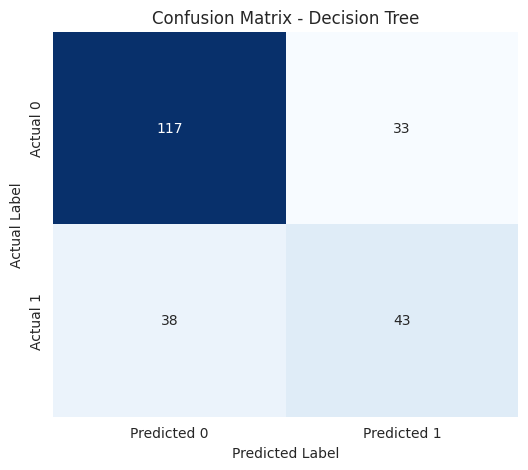

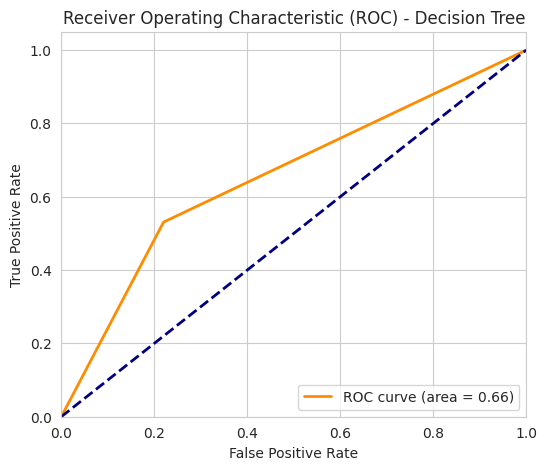

Decision Tree model saved to 'models/decision_tree.pkl'


In [25]:
# Initialize and train Decision Tree Classifier model
print("\nTraining Decision Tree Classifier Model...")
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_dt = dt_model.predict(X_test)
y_prob_dt = dt_model.predict_proba(X_test)[:, 1]

# Evaluate Decision Tree Classifier model
print("\n--- Decision Tree Classifier Model Evaluation ---")
accuracy_dt = accuracy_score(y_test, y_pred_dt)
precision_dt = precision_score(y_test, y_pred_dt)
recall_dt = recall_score(y_test, y_pred_dt)
f1_dt = f1_score(y_test, y_pred_dt)

print(f"Accuracy: {accuracy_dt:.4f}")
print(f"Precision: {precision_dt:.4f}")
print(f"Recall: {recall_dt:.4f}")
print(f"F1-Score: {f1_dt:.4f}")

# Confusion Matrix
cm_dt = confusion_matrix(y_test, y_pred_dt)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted 0', 'Predicted 1'], yticklabels=['Actual 0', 'Actual 1'])
plt.title('Confusion Matrix - Decision Tree')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.savefig(os.path.join(VISUALIZATIONS_DIR, 'confusion_matrix_dt.png'), dpi=300, bbox_inches='tight')
plt.show()

# ROC Curve and AUC
fpr_dt, tpr_dt, _ = roc_curve(y_test, y_prob_dt)
auc_dt = roc_auc_score(y_test, y_prob_dt)

plt.figure(figsize=(6, 5))
plt.plot(fpr_dt, tpr_dt, color='darkorange', lw=2, label=f'ROC curve (area = {auc_dt:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) - Decision Tree')
plt.legend(loc="lower right")
plt.savefig(os.path.join(VISUALIZATIONS_DIR, 'roc_curve_dt.png'), dpi=300, bbox_inches='tight')
plt.show()

# Save the model
joblib.dump(dt_model, os.path.join(MODELS_DIR, 'decision_tree.pkl'))
print(f"Decision Tree model saved to '{MODELS_DIR}/decision_tree.pkl'")

### Observations

*   Decision Trees capture non-linear relationships in the data and are easy to visualize.
*   While potentially suffering from overfitting, they provide direct insights into decision rules.
*   Performance is generally competitive, but often benefits from ensemble methods.

### Random Forest


Training Random Forest Classifier Model...

--- Random Forest Classifier Model Evaluation ---
Accuracy: 0.7403
Precision: 0.6667
Recall: 0.5185
F1-Score: 0.5833


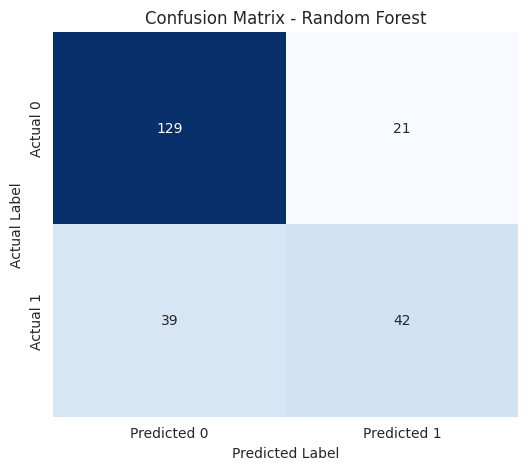

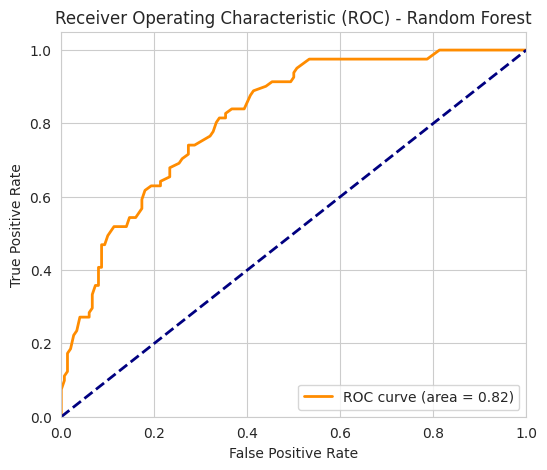

Random Forest model saved to 'models/random_forest.pkl'


In [26]:
# Initialize and train Random Forest Classifier model
print("\nTraining Random Forest Classifier Model...")
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

# Evaluate Random Forest Classifier model
print("\n--- Random Forest Classifier Model Evaluation ---")
accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)

print(f"Accuracy: {accuracy_rf:.4f}")
print(f"Precision: {precision_rf:.4f}")
print(f"Recall: {recall_rf:.4f}")
print(f"F1-Score: {f1_rf:.4f}")

# Confusion Matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted 0', 'Predicted 1'], yticklabels=['Actual 0', 'Actual 1'])
plt.title('Confusion Matrix - Random Forest')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.savefig(os.path.join(VISUALIZATIONS_DIR, 'confusion_matrix_rf.png'), dpi=300, bbox_inches='tight')
plt.show()

# ROC Curve and AUC
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
auc_rf = roc_auc_score(y_test, y_prob_rf)

plt.figure(figsize=(6, 5))
plt.plot(fpr_rf, tpr_rf, color='darkorange', lw=2, label=f'ROC curve (area = {auc_rf:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) - Random Forest')
plt.legend(loc="lower right")
plt.savefig(os.path.join(VISUALIZATIONS_DIR, 'roc_curve_rf.png'), dpi=300, bbox_inches='tight')
plt.show()

# Save the model
joblib.dump(rf_model, os.path.join(MODELS_DIR, 'random_forest.pkl'))
print(f"Random Forest model saved to '{MODELS_DIR}/random_forest.pkl'")

### Observations

*   Random Forest, an ensemble method, generally provides robust performance by combining multiple decision trees.
*   It effectively reduces overfitting and improves generalization compared to individual decision trees.
*   It often achieves the best overall balance between accuracy and generalization, making it a strong candidate for this type of predictive task.


--- Feature Importance (from Random Forest) ---

Top features contributing to diabetes prediction:


,Feature,Importance
1,Glucose,0.272161
5,BMI,0.151320
7,Age,0.129989
6,DiabetesPedigreeFunction,0.118306
0,Pregnancies,0.096944
2,BloodPressure,0.089079
4,Insulin,0.073077
3,SkinThickness,0.069124


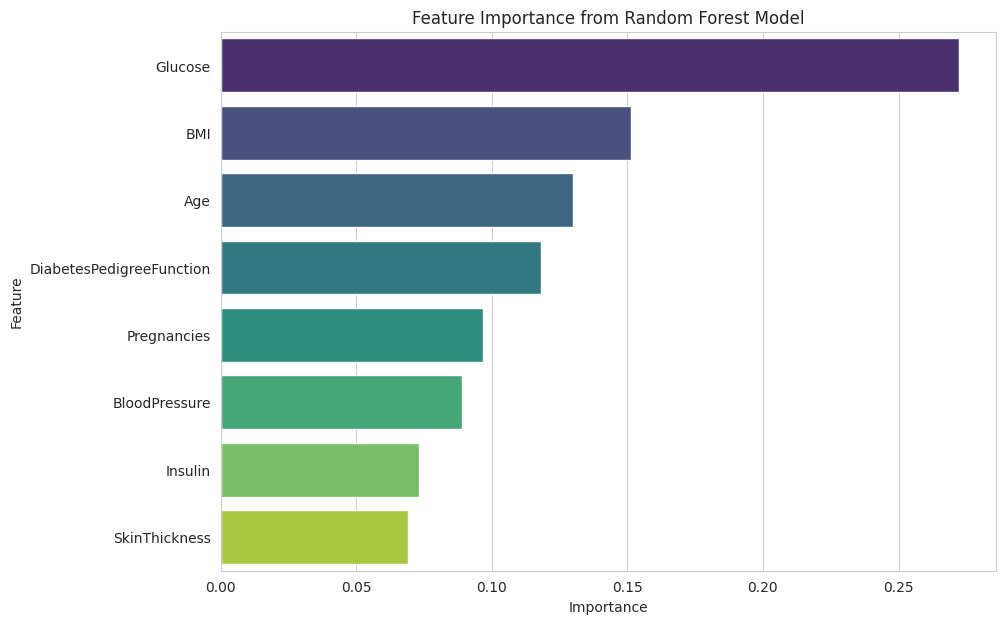


Understanding feature importance is crucial for clinical risk analysis, as it helps identify which patient indicators (e.g., Glucose, BMI, Age, Pregnancies) have the most significant impact on diabetes prediction. This insight can guide further medical research and interventions.


In [12]:
print("\n--- Feature Importance (from Random Forest) ---")

# Get feature importances from the Random Forest model
feature_importances = rf_model.feature_importances_

# Create a Series for better visualization
features_df = pd.DataFrame({'Feature': X.columns, 'Importance': feature_importances})
features_df = features_df.sort_values(by='Importance', ascending=False)

# Display feature importances
print("\nTop features contributing to diabetes prediction:")
display(features_df)

# Plot feature importances
plt.figure(figsize=(10, 7))
sns.barplot(x='Importance', y='Feature', data=features_df, palette='viridis', hue='Feature', legend=False) # Fixed FutureWarning
plt.title('Feature Importance from Random Forest Model')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

print("\nUnderstanding feature importance is crucial for clinical risk analysis, as it helps identify which patient indicators (e.g., Glucose, BMI, Age, Pregnancies) have the most significant impact on diabetes prediction. This insight can guide further medical research and interventions.")

## 11. Model Comparison


--- Model Comparison ---

Comparison of Model Performance Metrics:


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.7489,0.6949,0.5062,0.5857,0.8295
1,Decision Tree,0.6926,0.5658,0.5309,0.5478,0.6554
2,Random Forest,0.7403,0.6667,0.5185,0.5833,0.8159


Model performance metrics saved to 'results/model_metrics.csv'


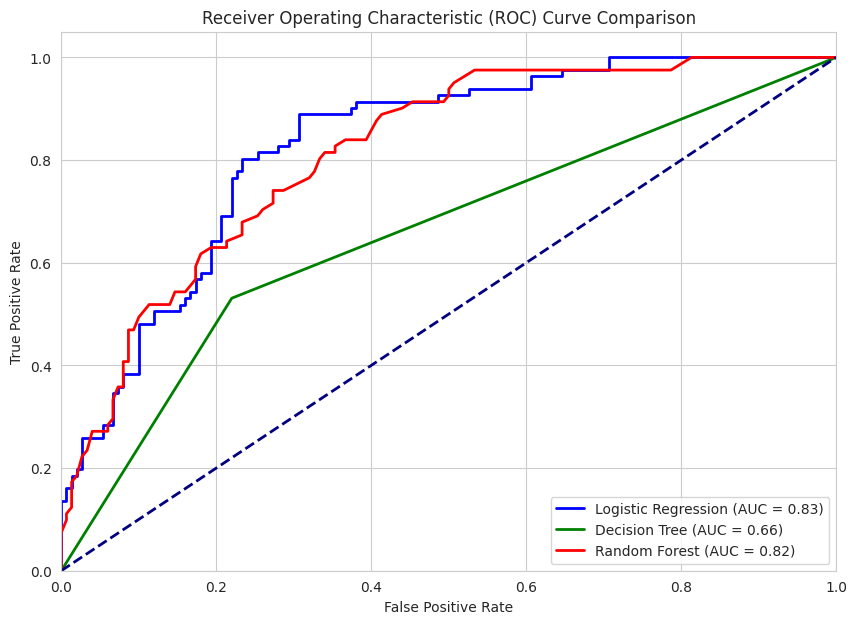

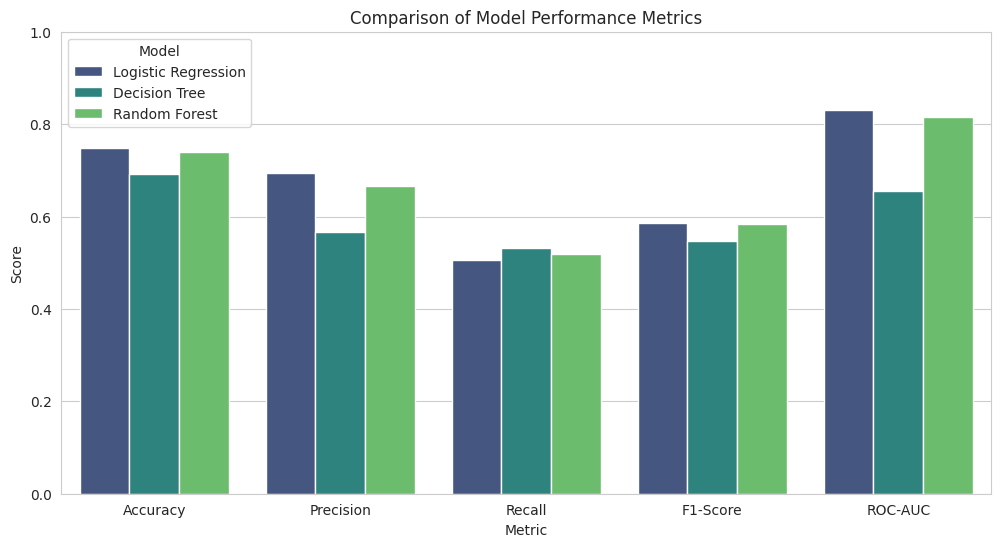

In [29]:
print("\n--- Model Comparison ---")

# Create a DataFrame to compare model performances
performance_data = {
    'Model': ['Logistic Regression', 'Decision Tree', 'Random Forest'],
    'Accuracy': [accuracy_lr, accuracy_dt, accuracy_rf],
    'Precision': [precision_lr, precision_dt, precision_rf],
    'Recall': [recall_lr, recall_dt, recall_rf],
    'F1-Score': [f1_lr, f1_dt, f1_rf],
    'ROC-AUC': [auc_lr, auc_dt, auc_rf]
}

performance_df = pd.DataFrame(performance_data)
performance_df = performance_df.round(4)

print("\nComparison of Model Performance Metrics:")
display(performance_df)

# Save performance metrics to results directory
RESULTS_DIR = 'results'
os.makedirs(RESULTS_DIR, exist_ok=True)
performance_df.to_csv(os.path.join(RESULTS_DIR, 'model_metrics.csv'), index=False)
print(f"Model performance metrics saved to '{RESULTS_DIR}/model_metrics.csv'")

# Visualize ROC curves for all models
plt.figure(figsize=(10, 7))
plt.plot(fpr_lr, tpr_lr, color='blue', lw=2, label=f'Logistic Regression (AUC = {auc_lr:.2f})')
plt.plot(fpr_dt, tpr_dt, color='green', lw=2, label=f'Decision Tree (AUC = {auc_dt:.2f})')
plt.plot(fpr_rf, tpr_rf, color='red', lw=2, label=f'Random Forest (AUC = {auc_rf:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve Comparison')
plt.legend(loc="lower right")
plt.savefig(os.path.join(VISUALIZATIONS_DIR, 'roc_curve_comparison.png'), dpi=300, bbox_inches='tight')
plt.show()

# Bar chart for comparing metrics
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
performance_df_melted = performance_df.melt(id_vars='Model', value_vars=metrics, var_name='Metric', value_name='Score')

plt.figure(figsize=(12, 6))
sns.barplot(x='Metric', y='Score', hue='Model', data=performance_df_melted, palette='viridis')
plt.title('Comparison of Model Performance Metrics')
plt.ylabel('Score')
plt.ylim(0, 1) # Metrics are usually between 0 and 1
plt.savefig(os.path.join(VISUALIZATIONS_DIR, 'model_performance_barchart.png'), dpi=300, bbox_inches='tight')
plt.show()

In [32]:
print("\n--- Saving Model Predictions ---")

# Create a DataFrame to store all predictions
predictions_df = pd.DataFrame({
    'Actual_Outcome': y_test,
    'LogisticRegression_Predicted': y_pred_lr,
    'LogisticRegression_Probability_1': y_prob_lr,
    'DecisionTree_Predicted': y_pred_dt,
    'DecisionTree_Probability_1': y_prob_dt,
    'RandomForest_Predicted': y_pred_rf,
    'RandomForest_Probability_1': y_prob_rf
})

# Reset index to make 'Actual_Outcome' align correctly with predictions
predictions_df = predictions_df.reset_index(drop=True)

# Save predictions to results directory
RESULTS_DIR = 'results'
os.makedirs(RESULTS_DIR, exist_ok=True) # Ensure results directory exists
predictions_df.to_csv(os.path.join(RESULTS_DIR, 'predictions.csv'), index=False)
print(f"All model predictions saved to '{RESULTS_DIR}/predictions.csv'")
display(predictions_df.head())


--- Saving Model Predictions ---
All model predictions saved to 'results/predictions.csv'


,Actual_Outcome,LogisticRegression_Predicted,LogisticRegression_Probability_1,DecisionTree_Predicted,DecisionTree_Probability_1,RandomForest_Predicted,RandomForest_Probability_1
0,1,0,0.271648,0,0.0,0,0.13
1,1,0,0.307126,1,1.0,0,0.30
2,1,1,0.630007,1,1.0,1,0.88
3,1,1,0.539986,0,0.0,1,0.60
4,1,0,0.324444,0,0.0,1,0.62


## 12. Feature Importance


--- Feature Importance (from Random Forest) ---

Top features contributing to diabetes prediction:


,Feature,Importance
1,Glucose,0.268015
5,BMI,0.158051
7,Age,0.122681
6,DiabetesPedigreeFunction,0.116073
4,Insulin,0.091462
0,Pregnancies,0.088386
2,BloodPressure,0.087170
3,SkinThickness,0.068162


Feature importance saved to 'results/feature_importance.csv'


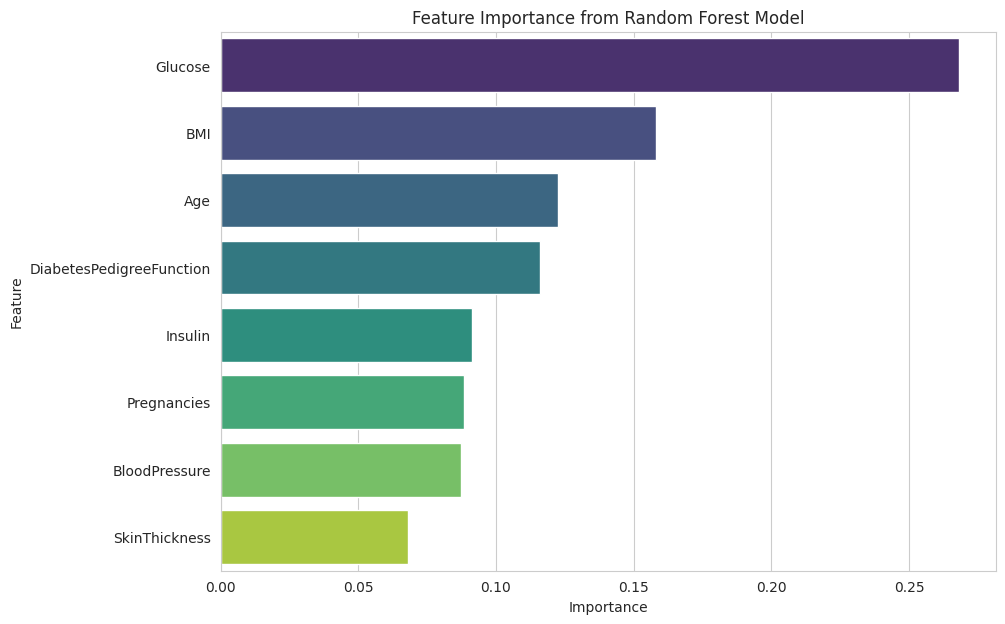

In [30]:
print("\n--- Feature Importance (from Random Forest) ---")

# Get feature importances from the Random Forest model
feature_importances = rf_model.feature_importances_

# Create a Series for better visualization
features_df = pd.DataFrame({'Feature': X.columns, 'Importance': feature_importances})
features_df = features_df.sort_values(by='Importance', ascending=False)

# Display feature importances
print("\nTop features contributing to diabetes prediction:")
display(features_df)

# Save feature importance to results directory
RESULTS_DIR = 'results'
os.makedirs(RESULTS_DIR, exist_ok=True) # Ensure results directory exists
features_df.to_csv(os.path.join(RESULTS_DIR, 'feature_importance.csv'), index=False)
print(f"Feature importance saved to '{RESULTS_DIR}/feature_importance.csv'")

# Plot feature importances
plt.figure(figsize=(10, 7))
sns.barplot(x='Importance', y='Feature', data=features_df, palette='viridis', hue='Feature', legend=False)
plt.title('Feature Importance from Random Forest Model')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.savefig(os.path.join(VISUALIZATIONS_DIR, 'feature_importance.png'), dpi=300, bbox_inches='tight')
plt.show()

### Observations

*   Feature importance analysis helps identify which patient indicators (e.g., Glucose, BMI, Age) have the most significant impact on diabetes prediction.
*   This insight is crucial for clinical understanding, patient counseling, and guiding further medical research or interventions related to diabetes prevention and management.

## 13. Conclusion

This project demonstrates that healthcare datasets can be effectively analyzed using statistical methods and machine learning techniques. Among the evaluated models, Random Forest achieved the strongest predictive performance due to its ensemble learning approach. Feature importance analysis identified Glucose, BMI, Age, and Insulin as the most influential clinical indicators. The project highlights how data analytics can support evidence-based clinical decision making and serve as a foundation for future medical AI research.

## 14. Future Work

*   Hyperparameter tuning using GridSearchCV/RandomizedSearchCV.
*   XGBoost or LightGBM implementation for boosted models.
*   SHAP or LIME for model explainability.
*   Deployment using FastAPI and Streamlit for interactive dashboards.
*   Docker Containerization for reproducible environments.
*   Collect more diverse data to address potential biases and improve generalization.

In [33]:
print("\n--- Generating requirements.txt ---")

# List of common libraries used in this project
# You can extend this list if you use other specific libraries
installed_packages = [
    'pandas',
    'numpy',
    'matplotlib',
    'seaborn',
    'scikit-learn',
    'joblib',
    'sqlite3' # sqlite3 is usually built-in, but good to mention dependencies
]

# Get current versions of installed packages
# This method checks if package is importable and then gets its version
def get_package_version(package_name):
    try:
        module = __import__(package_name.replace('-', '_'))
        version = getattr(module, '__version__', 'N/A')
        if version == 'N/A' and hasattr(module, 'version'):
            version = module.version
        return f"{package_name}=={version}"
    except ImportError:
        return f"# {package_name} (not found)"
    except Exception as e:
        return f"# {package_name} (error: {e})"

# Generate requirements.txt content
requirements_content = []
for package in installed_packages:
    requirements_content.append(get_package_version(package))

# Add jupyter for notebook environment
requirements_content.append('jupyter')

# Write to requirements.txt
REQUIREMENTS_FILE = 'requirements.txt'
with open(REQUIREMENTS_FILE, 'w') as f:
    f.write('\n'.join(requirements_content))

print(f"'{REQUIREMENTS_FILE}' generated successfully.")
print("Content of requirements.txt:")
with open(REQUIREMENTS_FILE, 'r') as f:
    print(f.read())


--- Generating requirements.txt ---
'requirements.txt' generated successfully.
Content of requirements.txt:
pandas==2.2.2
numpy==2.0.2
matplotlib==3.10.0
seaborn==0.13.2
# scikit-learn (not found)
joblib==1.5.3
sqlite3==2.6.0
jupyter


/tmp/ipykernel_1990/1116652374.py:21: DeprecationWarning: version is deprecated and will be removed in Python 3.14
  if version == 'N/A' and hasattr(module, 'version'):
/tmp/ipykernel_1990/1116652374.py:22: DeprecationWarning: version is deprecated and will be removed in Python 3.14
  version = module.version
